In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [7]:
def count_linear_track_laps(
    session_df,
    x_col="X_coor",
    time_col="Time Stamp (ms)",
    smooth_window=5,
    end_zone_quantile=0.10,
):
    """
    Count end-to-end traversals on a linear track.

    Definition used here:
    - entering the opposite end zone after leaving one end zone counts as 1 lap
    - left->right and right->left are both counted

    Returns a dict of lap stats.
    """
    x = pd.to_numeric(session_df[x_col], errors="coerce")

    if smooth_window and smooth_window > 1:
        x_smooth = x.rolling(smooth_window, center=True, min_periods=1).median()
    else:
        x_smooth = x.copy()

    valid_x = x_smooth.dropna()
    if valid_x.empty:
        return {
            "laps_total": np.nan,
            "laps_left_to_right": np.nan,
            "laps_right_to_left": np.nan,
            "duration_s": np.nan,
            "laps_per_min": np.nan,
            "left_thresh": np.nan,
            "right_thresh": np.nan,
        }

    left_thresh = valid_x.quantile(end_zone_quantile)
    right_thresh = valid_x.quantile(1 - end_zone_quantile)

    if right_thresh <= left_thresh:
        return {
            "laps_total": np.nan,
            "laps_left_to_right": np.nan,
            "laps_right_to_left": np.nan,
            "duration_s": np.nan,
            "laps_per_min": np.nan,
            "left_thresh": left_thresh,
            "right_thresh": right_thresh,
        }

    def zone_of(v):
        if pd.isna(v):
            return np.nan
        if v <= left_thresh:
            return "left"
        if v >= right_thresh:
            return "right"
        return "middle"

    zones = x_smooth.map(zone_of)

    current_end = None
    armed = False
    laps_total = 0
    laps_left_to_right = 0
    laps_right_to_left = 0

    for zone in zones:
        if pd.isna(zone):
            continue

        if current_end is None:
            if zone in ("left", "right"):
                current_end = zone
            continue

        if zone == "middle":
            armed = True
            continue

        if zone == current_end:
            continue

        # opposite end reached
        if armed and zone in ("left", "right"):
            laps_total += 1
            if current_end == "left" and zone == "right":
                laps_left_to_right += 1
            elif current_end == "right" and zone == "left":
                laps_right_to_left += 1

            current_end = zone
            armed = False

    if time_col in session_df.columns:
        t = pd.to_numeric(session_df[time_col], errors="coerce")
        duration_s = (t.dropna().iloc[-1] - t.dropna().iloc[0]) / 1000 if t.dropna().shape[0] >= 2 else np.nan
    else:
        duration_s = np.nan

    laps_per_min = laps_total / (duration_s / 60) if pd.notna(duration_s) and duration_s > 0 else np.nan

    return {
        "laps_total": laps_total,
        "laps_left_to_right": laps_left_to_right,
        "laps_right_to_left": laps_right_to_left,
        "duration_s": duration_s,
        "laps_per_min": laps_per_min,
        "left_thresh": left_thresh,
        "right_thresh": right_thresh,
    }

In [8]:
base_dir = Path("/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackEzTrack")

smooth_window = 5
end_zone_quantile = 0.10

mouse_dirs = sorted(base_dir.glob("aligned_miniscope_to_eztrack_*"))

session_tasks = []
for mouse_dir in mouse_dirs:
    mouse_id = mouse_dir.name.split("_")[-1]
    session_csvs = sorted(
        p for p in mouse_dir.glob("*_miniscopeAlignedToEzTrack.csv")
        if not p.name.startswith("mouse_")
    )
    for csv_path in session_csvs:
        session_tasks.append((mouse_id, csv_path))

lap_rows = []

for mouse_id, csv_path in tqdm(session_tasks, desc="Counting laps", unit="session"):
    session_df = pd.read_csv(csv_path)

    lap_stats = count_linear_track_laps(
        session_df,
        x_col="X_coor",
        time_col="Time Stamp (ms)",
        smooth_window=smooth_window,
        end_zone_quantile=end_zone_quantile,
    )

    lap_rows.append({
        "mouse": mouse_id,
        "session_file": csv_path.name,
        "session": csv_path.name.replace("_miniscopeAlignedToEzTrack.csv", ""),
        "n_rows": len(session_df),
        "smooth_window": smooth_window,
        "end_zone_quantile": end_zone_quantile,
        **lap_stats,
    })

lap_session_df = pd.DataFrame(lap_rows).sort_values(["mouse", "session"]).reset_index(drop=True)

lap_mouse_df = (
    lap_session_df
    .groupby("mouse", as_index=False)
    .agg(
        n_sessions=("session", "count"),
        total_rows=("n_rows", "sum"),
        laps_total=("laps_total", "sum"),
        laps_left_to_right=("laps_left_to_right", "sum"),
        laps_right_to_left=("laps_right_to_left", "sum"),
        total_duration_s=("duration_s", "sum"),
    )
)

lap_mouse_df["laps_per_min_overall"] = lap_mouse_df["laps_total"] / (lap_mouse_df["total_duration_s"] / 60)

lap_session_df.head(), lap_mouse_df


Counting laps: 100%|████████████████████| 116/116 [02:24<00:00,  1.24s/session]


(  mouse                                     session_file            session  \
 0   311  02042025_19_15_29_miniscopeAlignedToEzTrack.csv  02042025_19_15_29   
 1   311  03042025_15_39_01_miniscopeAlignedToEzTrack.csv  03042025_15_39_01   
 2   311  04042025_21_05_03_miniscopeAlignedToEzTrack.csv  04042025_21_05_03   
 3   311  05042025_18_35_11_miniscopeAlignedToEzTrack.csv  05042025_18_35_11   
 4   311  05042025_19_12_36_miniscopeAlignedToEzTrack.csv  05042025_19_12_36   
 
    n_rows  smooth_window  end_zone_quantile  laps_total  laps_left_to_right  \
 0   23700              5                0.1          45                  23   
 1   23692              5                0.1          69                  34   
 2   23693              5                0.1          80                  40   
 3   15691              5                0.1          25                  13   
 4   23693              5                0.1          11                   6   
 
    laps_right_to_left  duration_s  

/Users/johnmarshall/Documents/Presentations/05192026/WT_vs_A636T_mean_laps_per_session.pdf


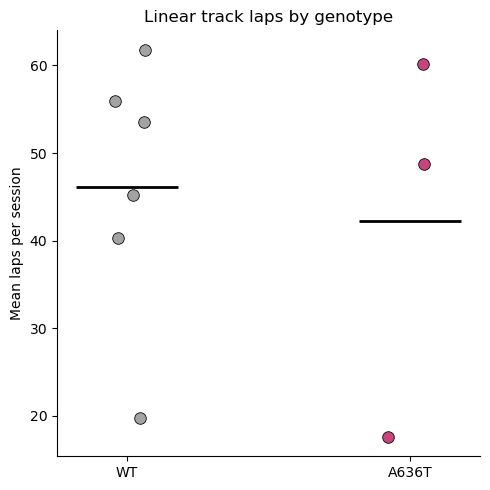

,mouse,mean_laps_per_session,genotype
0,311,45.166667,WT
1,326,61.800000,WT
2,328,17.600000,A636T
3,388,48.800000,A636T
4,752,60.187500,A636T
5,757,19.800000,WT
6,989,56.000000,WT
7,992,40.333333,WT
8,994,53.600000,WT


In [10]:
# genotype groups
wt_ids = [992, 994, 989, 757, 326, 311]
mut_ids = [752, 328, 388]

wt_mice = [str(x) for x in wt_ids]
mut_mice = [str(x) for x in mut_ids]

# one value per mouse = average laps across that mouse's sessions
lap_mouse_avg_df = (
    lap_session_df
    .groupby("mouse", as_index=False)["laps_total"]
    .mean()
    .rename(columns={"laps_total": "mean_laps_per_session"})
)

lap_mouse_avg_df["genotype"] = pd.Series(pd.NA, index=lap_mouse_avg_df.index, dtype="object")
lap_mouse_avg_df.loc[lap_mouse_avg_df["mouse"].astype(str).isin(wt_mice), "genotype"] = "WT"
lap_mouse_avg_df.loc[lap_mouse_avg_df["mouse"].astype(str).isin(mut_mice), "genotype"] = "A636T"
lap_mouse_avg_df = lap_mouse_avg_df.dropna(subset=["genotype"]).copy()

# plotting
colors = {"WT": "#9e9e9e", "A636T": "#c23b75"}
xpos = {"WT": 0, "A636T": 1}
rng = np.random.default_rng(7)

fig, ax = plt.subplots(figsize=(5, 5))

for genotype in ["WT", "A636T"]:
    sub = lap_mouse_avg_df.loc[lap_mouse_avg_df["genotype"] == genotype].copy()
    vals = sub["mean_laps_per_session"].to_numpy()

    jitter = rng.uniform(-0.08, 0.08, len(vals))
    ax.scatter(
        np.full(len(vals), xpos[genotype]) + jitter,
        vals,
        s=70,
        color=colors[genotype],
        edgecolor="black",
        linewidth=0.6,
        alpha=0.95,
        zorder=3,
    )

    mean_val = vals.mean()
    ax.hlines(mean_val, xpos[genotype] - 0.18, xpos[genotype] + 0.18,
              color="black", linewidth=2)

ax.set_xticks([0, 1])
ax.set_xticklabels(["WT", "A636T"])
ax.set_ylabel("Mean laps per session")
ax.set_title("Linear track laps by genotype")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

save_dir = Path("/Users/johnmarshall/Documents/Presentations/05192026")
save_dir.mkdir(parents=True, exist_ok=True)

pdf_path = save_dir / "WT_vs_A636T_mean_laps_per_session.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(pdf_path)

plt.show()

lap_mouse_avg_df


In [11]:
session_summary_df = (
    lap_session_df
    .groupby("mouse", as_index=False)
    .agg(
        n_sessions=("session", "nunique"),
        mean_laps_per_session=("laps_total", "mean"),
        total_laps=("laps_total", "sum"),
        total_duration_s=("duration_s", "sum"),
    )
    .sort_values("mouse")
    .reset_index(drop=True)
)

session_summary_df


,mouse,n_sessions,mean_laps_per_session,total_laps,total_duration_s
0,311,12,45.166667,542,13750.363
1,326,10,61.800000,618,12002.692
2,328,10,17.600000,176,12001.732
3,388,10,48.800000,488,12002.503
4,752,16,60.187500,963,17110.077
5,757,5,19.800000,99,5109.127
6,989,17,56.000000,952,16534.854
7,992,21,40.333333,847,19790.507
8,994,15,53.600000,804,14710.014
